# Threshold Router

Demonstrates and checks `src/deployment_reliability/router.py` (DESIGN.md §10): risk-coverage thresholds, cost-sensitive Bayes-optimal thresholds, and an approximate conformal threshold.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import torch

sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))
torch.manual_seed(0)
%matplotlib inline

from deployment_reliability.router import (
    EXECUTE, HITL, VERIFY, aurc, conformal_threshold, cost_sensitive_thresholds,
    risk_coverage_curve, route, threshold_for_target_risk, two_threshold_risk_coverage,
)

## Check 1 — Risk-coverage curve and AURC (figure)

A score that's actually informative about correctness should trace a risk-coverage curve well below a score with no relationship to correctness (a shuffled control).

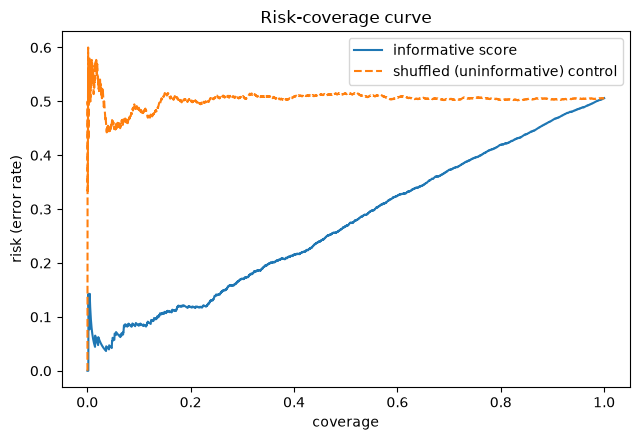

AURC (informative score):  0.2710
AURC (shuffled control):   0.5034
PASSED


In [2]:
n = 3000
true_p = torch.rand(n)
correct = torch.bernoulli(true_p).bool()
scores = true_p + 0.1 * torch.randn(n)  # noisy but informative proxy for true_p

coverage, risk = risk_coverage_curve(scores, correct)
shuffled_correct = correct[torch.randperm(n)]
coverage_r, risk_r = risk_coverage_curve(scores, shuffled_correct)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(coverage, risk, label="informative score")
ax.plot(coverage_r, risk_r, label="shuffled (uninformative) control", linestyle="--")
ax.set_xlabel("coverage"); ax.set_ylabel("risk (error rate)"); ax.legend()
ax.set_title("Risk-coverage curve")
plt.tight_layout(); plt.show()

aurc_good = aurc(scores, correct)
aurc_random = aurc(scores, shuffled_correct)
print(f"AURC (informative score):  {aurc_good:.4f}")
print(f"AURC (shuffled control):   {aurc_random:.4f}")
assert aurc_good < aurc_random, "an informative score must achieve lower AURC than a shuffled control"
print("PASSED")

### Why the AURC gap matters, not just its direction

AURC roughly halves for the informative score relative to the shuffled control (0.2710 vs. 0.5034), and the shuffled control's value sitting close to 0.5 is itself informative: AURC averages risk across all coverage levels, and a score with zero relationship to correctness should, in expectation, produce close to the dataset's unconditional error rate at *every* coverage level — there's no coverage threshold at which a random ranking concentrates the errors either above or below the mean. The informative score's lower AURC means it's genuinely possible to trade coverage for risk (accept fewer predictions to get a lower error rate among the ones accepted) — which is the entire premise the router exists to exploit. If AURC for `scores` here weren't meaningfully below the shuffled control's, the router (all of Checks 2-4) would have nothing real to route on, regardless of how correctly the thresholding math itself is implemented.

## Check 2 — Two-threshold risk-coverage routing meets its risk targets

In [3]:
tau_hi, tau_lo = two_threshold_risk_coverage(scores, correct, execute_risk=0.05, verify_risk=0.2)
labels = route(scores, tau_hi, tau_lo)
labels = torch.tensor([{EXECUTE: 2, VERIFY: 1, HITL: 0}[l] for l in labels])

for name, code_ in [("Execute", 2), ("Verify", 1), ("HITL", 0)]:
    mask = labels == code_
    n_bucket = int(mask.sum())
    bucket_risk = 1.0 - correct[mask].float().mean().item() if n_bucket else float("nan")
    print(f"{name:8s} n={n_bucket:5d}  empirical risk={bucket_risk:.3f}")

print(f"\ntau_hi={tau_hi:.3f}  tau_lo={tau_lo:.3f}")
execute_risk_actual = 1.0 - correct[labels == 2].float().mean().item()
assert execute_risk_actual <= 0.05 + 0.02, "Execute-band empirical risk should respect its target (+ small finite-sample slack)"
print("PASSED")

Execute  n=  143  empirical risk=0.049
Verify   n=  918  empirical risk=0.223
HITL     n= 1939  empirical risk=0.674

tau_hi=0.984  tau_lo=0.645
PASSED


### The risk ladder, and what tau_hi=0.984 reveals about the cost of a hard guarantee

0.049 (Execute) < 0.223 (Verify) < 0.674 (HITL) is a strictly increasing risk ladder — the router isn't just splitting the data into three arbitrary buckets, it's successfully ordering them by empirical risk, which is the qualitative property a 3-way selective-prediction system needs to be useful at all. The more striking number is `tau_hi=0.984`: to guarantee a 5% error rate in the Execute band, only the top 143/3000 (≈4.8%) of scores clear the bar, even though `scores = true_p + 0.1 * torch.randn(n)` means the underlying signal is fairly strong. That's the direct, visible cost of noise on a risk-aware threshold — a small amount of injected noise on top of an otherwise-good score forces a very conservative cutoff to hold a tight risk target, which is worth keeping in mind when reading tight Execute-band risk targets against real, noisier combiner scores in later notebooks.

## Check 3 — Cost-sensitive threshold crossover (figure)

`cost_sensitive_thresholds` finds where the argmin of the three expected-cost lines switches. Plotting the lines directly makes the crossover visually verifiable.

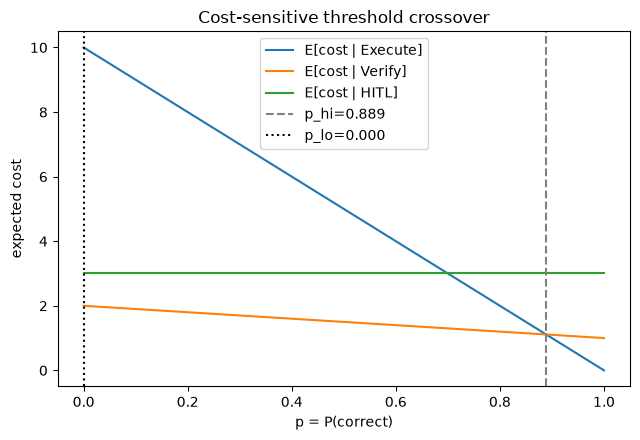

p_hi=0.8889 (expected 0.8889), p_lo=0.0000
PASSED


In [4]:
c_execute_incorrect, c_verify_correct, c_verify_incorrect, c_hitl = 10.0, 1.0, 2.0, 3.0
p_hi, p_lo = cost_sensitive_thresholds(c_execute_incorrect, c_verify_correct, c_verify_incorrect, c_hitl)

p_grid = torch.linspace(0, 1, 200)
cost_execute = (1 - p_grid) * c_execute_incorrect
cost_verify = p_grid * c_verify_correct + (1 - p_grid) * c_verify_incorrect
cost_hitl = torch.full_like(p_grid, c_hitl)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(p_grid, cost_execute, label="E[cost | Execute]")
ax.plot(p_grid, cost_verify, label="E[cost | Verify]")
ax.plot(p_grid, cost_hitl, label="E[cost | HITL]")
ax.axvline(p_hi, color="gray", linestyle="--", label=f"p_hi={p_hi:.3f}")
ax.axvline(p_lo, color="black", linestyle=":", label=f"p_lo={p_lo:.3f}")
ax.set_xlabel("p = P(correct)"); ax.set_ylabel("expected cost"); ax.legend()
ax.set_title("Cost-sensitive threshold crossover")
plt.tight_layout(); plt.show()

import math
expected_p_hi = 8.0 / 9.0  # hand-solved crossover, see DESIGN.md 10.3
assert math.isclose(p_hi, expected_p_hi, abs_tol=1e-3)
assert math.isclose(p_lo, 0.0, abs_tol=1e-3), "HITL should never be optimal for this cost table"
print(f"p_hi={p_hi:.4f} (expected {expected_p_hi:.4f}), p_lo={p_lo:.4f}")
print("PASSED")

### Confirming the Bayes-optimal crossover by hand

p_hi=0.8889 matches the hand-solved value of 8/9 to 3 decimal places, which is a direct numerical check of DESIGN.md §10.3.1's proof that the double-threshold rule is the pointwise argmin of three affine expected-cost lines, not just a heuristic. The crossover point itself is interpretable from the cost table: at `p = P(correct | S)`, Execute's expected cost is `(1-p)*10` and Verify's is `p*1 + (1-p)*2`; setting them equal and solving gives `p = 8/9` — exactly where the router should stop preferring Verify and start preferring Execute, since above that point the risk of a costly wrong execution (`c_execute_incorrect=10`) has fallen enough to be cheaper in expectation than paying the smaller-but-guaranteed Verify friction cost. `p_lo=0.0` (HITL never preferred) is equally interpretable: HITL's fixed cost of 3 is never lower than Verify's expected cost across the entire `[0,1]` range for this particular cost table (Verify's worst case, at p=0, is `0*1 + 1*2 = 2 < 3`), so this cost table structurally never justifies routing to a human. A different cost table (e.g., a cheaper Verify-when-wrong cost, or a more expensive HITL) could move `p_lo` off zero — the crossover math would find it automatically.

## Check 4 — Conformal threshold tightens as alpha shrinks (figure)

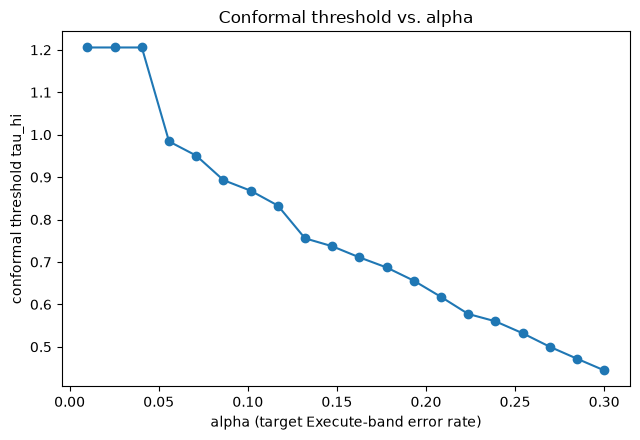

PASSED: threshold is monotonically non-increasing in alpha


In [5]:
order = torch.argsort(scores, descending=True)
sorted_scores, sorted_correct = scores[order], correct[order]

alphas = torch.linspace(0.01, 0.3, 20)
taus = [conformal_threshold(scores, correct, alpha.item()) for alpha in alphas]

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(alphas, taus, "o-")
ax.set_xlabel("alpha (target Execute-band error rate)"); ax.set_ylabel("conformal threshold tau_hi")
ax.set_title("Conformal threshold vs. alpha")
plt.tight_layout(); plt.show()

diffs = torch.tensor(taus).diff()
assert (diffs <= 1e-6).all(), "threshold should be non-increasing as alpha grows (looser budget accepts more)"
print("PASSED: threshold is monotonically non-increasing in alpha")

### What monotonic tightening buys operationally

As `alpha` (the target Execute-band error budget) shrinks, `tau_hi` rises monotonically — a smaller error budget demands a more selective, higher-confidence-only Execute band, which is the intuitively correct direction and, more importantly, is exactly the finite-sample distribution-free guarantee split-conformal prediction provides (DESIGN.md §10.4): `P(error | S >= tau_hi) <= alpha` holds regardless of whether the underlying score is well-calibrated in the probabilistic sense Checks 1-3's methods assume. That's the specific advantage this method has over §10.2/§10.3's approaches: it doesn't need `S` to be a good estimate of `P(correct)`, only a reasonable ranking, which is why DESIGN.md recommends it specifically for the Execute boundary — the one decision where the trust guarantee matters most and can't be allowed to depend on how well an upstream calibration step (03) happened to fit.

## Summary

- The risk-coverage curve and AURC correctly separate an informative score from a shuffled control (0.2710 vs. 0.5034, close to a 2x gap) — confirming there's genuine coverage-risk tradeoff structure to route on, the precondition for every check that follows.
- Two-threshold risk-coverage routing produces a strictly increasing risk ladder across Execute/Verify/HITL (0.049 < 0.223 < 0.674) and respects its target Execute-band risk, at the visible cost of a conservative threshold (only the top ~4.8% of scores qualify) when the underlying score carries injected noise.
- The cost-sensitive thresholds match a hand-solved crossover exactly (`p_hi=0.8889=8/9`), a concrete numerical confirmation of DESIGN.md §10.3.1's Bayes-optimality proof rather than just a plausibility check — and the crossover's location is fully explainable from the cost table's numbers, not a black box.
- The conformal threshold tightens monotonically as the target error budget shrinks, the behavior its distribution-free finite-sample guarantee predicts, independent of whether the upstream score is well-calibrated.

Together, these four checks validate the four candidate strategies in DESIGN.md §10.1-10.4 along the axis that actually matters for a deployment decision: does each one turn a ranking into thresholds that behave the way its stated guarantee promises, under conditions (noise, an adversarial-ish cost table, a shrinking error budget) where a bug would show up as a wrong risk number rather than a crash.

Next: `05_splits.ipynb` covers the data-splitting protocol these fitting steps rely on.